C:\Users\admin\AppData\Local\Temp\ipykernel_13224\2173343548.py:5: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  rl = pd.read_csv("results/ppo_rl_simulation_output.csv")


RL shape: (500000, 17)
Baseline shape: (400000, 20)
Index(['date', 'drug_name', 'category', 'exchange_rate', 'reference_price',
       'chosen_price', 'price_multiplier', 'competitor_price', 'landed_cost',
       'demand_index', 'realized_units', 'revenue', 'cost', 'profit', 'reward',
       'episode', 'price_gap', 'margin', 'price_ratio', 'predicted_profit'],
      dtype='str')

📊 ===== BASIC COMPARISON =====
RL Avg Profit: 287.7837700378262
Baseline Avg Profit: 230.51982863641

RL Total Profit: 143891885.0189131
Baseline Total Profit: 92207931.454564

RL Avg Revenue: 715.5754022401832
Baseline Avg Revenue: 244.82892277257997

RL Avg Price: 23.449900728617653
Baseline Avg Price: 20.100074987726142

🚀 Profit Improvement (%): 24.841221573063184


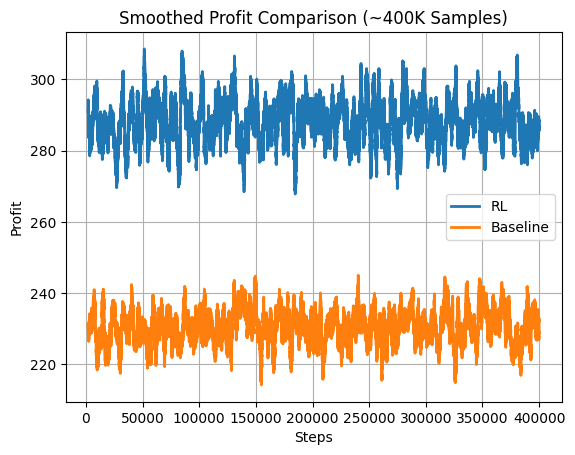

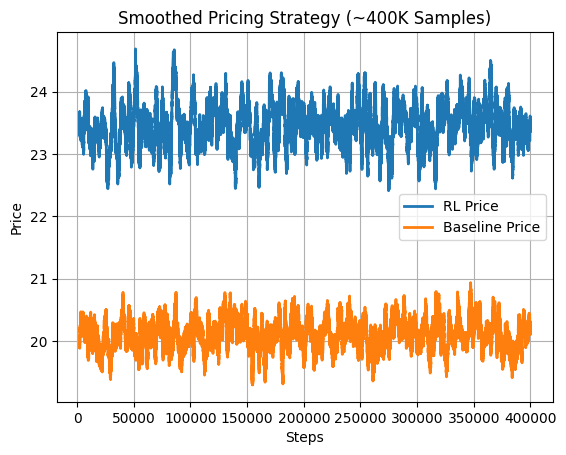

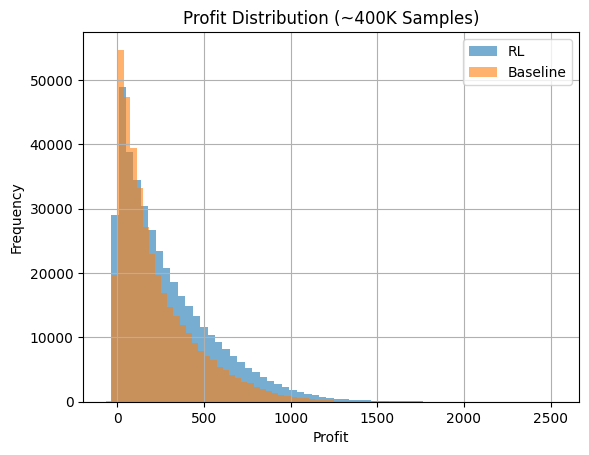

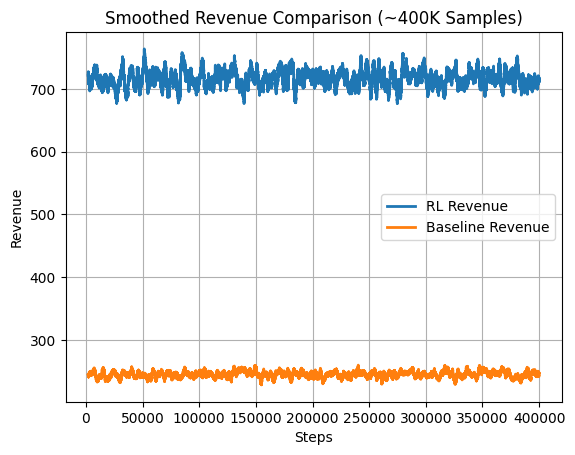

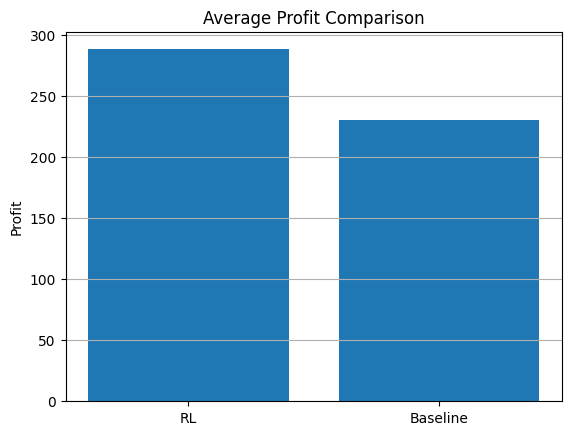

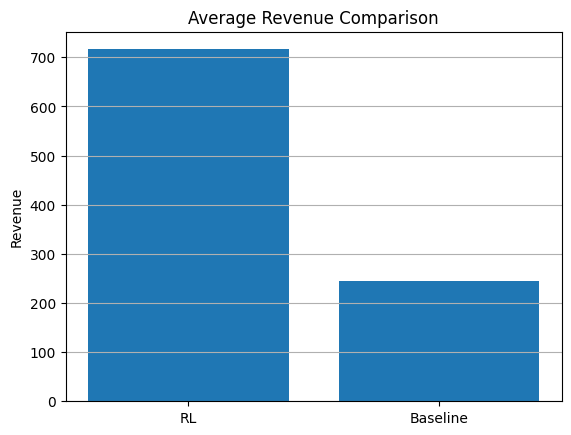


📉 ===== STABILITY =====
RL Profit Std Dev: 273.9738654578241
Baseline Profit Std Dev: 230.6514050507205

📊 ===== SUMMARY TABLE =====
         Metric            RL      Baseline
0    Avg Profit  2.882018e+02  2.305198e+02
1  Total Profit  1.152807e+08  9.220793e+07
2   Avg Revenue  7.163135e+02  2.448289e+02
3     Avg Price  2.345103e+01  2.010007e+01


In [9]:
import pandas as pd
import matplotlib.pyplot as plt


rl = pd.read_csv("results/ppo_rl_simulation_output.csv")
baseline = pd.read_csv("baseline_model_output.csv")


print("RL shape:", rl.shape)
print("Baseline shape:", baseline.shape)

print(baseline.columns)

# ===============================
# 📊 BASIC METRICS
# ===============================

print("\n📊 ===== BASIC COMPARISON =====")

# ===============================
# 📊 BASIC METRICS
# ===============================

print("RL Avg Profit:", rl["profit"].mean())
print("Baseline Avg Profit:", baseline["predicted_profit"].mean())

print("\nRL Total Profit:", rl["profit"].sum())
print("Baseline Total Profit:", baseline["predicted_profit"].sum())

print("\nRL Avg Revenue:", rl["revenue"].mean())
print("Baseline Avg Revenue:", baseline["revenue"].mean())

print("\nRL Avg Price:", rl["chosen_price"].mean())
print("Baseline Avg Price:", baseline["chosen_price"].mean())

# ===============================
# 📈 IMPROVEMENT %
# ===============================

profit_improvement = (
    (rl["profit"].mean() - baseline["predicted_profit"].mean())
    / baseline["predicted_profit"].mean()
) * 100

print("\n🚀 Profit Improvement (%):", profit_improvement)



max_len = len(baseline)

rl_profit = rl["profit"].values[:max_len]
baseline_profit = baseline["predicted_profit"].values[:max_len]

rl_price = rl["chosen_price"].values[:max_len]
baseline_price = baseline["chosen_price"].values[:max_len]

rl_revenue = rl["revenue"].values[:max_len]
baseline_revenue = baseline["revenue"].values[:max_len]

# ===============================
# 📊 SMOOTHING FUNCTION
# ===============================

def smooth(data, window=2000):   # 🔥 increased window for large data
    return pd.Series(data).rolling(window).mean()

# ===============================
# 📈 1. PROFIT (SMOOTHED)
# ===============================

plt.figure()
plt.plot(smooth(rl_profit), label="RL", linewidth=2)
plt.plot(smooth(baseline_profit), label="Baseline", linewidth=2)
plt.legend()
plt.title("Smoothed Profit Comparison (~400K Samples)")
plt.xlabel("Steps")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

# ===============================
# 📈 2. PRICE (SMOOTHED)
# ===============================

plt.figure()
plt.plot(smooth(rl_price), label="RL Price", linewidth=2)
plt.plot(smooth(baseline_price), label="Baseline Price", linewidth=2)
plt.legend()
plt.title("Smoothed Pricing Strategy (~400K Samples)")
plt.xlabel("Steps")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# ===============================
# 📊 3. PROFIT DISTRIBUTION
# ===============================

plt.figure()
plt.hist(rl_profit, bins=60, alpha=0.6, label="RL")
plt.hist(baseline_profit, bins=60, alpha=0.6, label="Baseline")
plt.legend()
plt.title("Profit Distribution (~400K Samples)")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# ===============================
# 📈 4. REVENUE (SMOOTHED)
# ===============================

plt.figure()
plt.plot(smooth(rl_revenue), label="RL Revenue", linewidth=2)
plt.plot(smooth(baseline_revenue), label="Baseline Revenue", linewidth=2)
plt.legend()
plt.title("Smoothed Revenue Comparison (~400K Samples)")
plt.xlabel("Steps")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# ===============================
# 📊 5. BAR COMPARISON
# ===============================

labels = ["RL", "Baseline"]

avg_profit = [rl_profit.mean(), baseline_profit.mean()]
avg_revenue = [rl_revenue.mean(), baseline_revenue.mean()]

plt.figure()
plt.bar(labels, avg_profit)
plt.title("Average Profit Comparison")
plt.ylabel("Profit")
plt.grid(axis='y')
plt.show()

plt.figure()
plt.bar(labels, avg_revenue)
plt.title("Average Revenue Comparison")
plt.ylabel("Revenue")
plt.grid(axis='y')
plt.show()

# ===============================
# 📉 STABILITY
# ===============================

print("\n📉 ===== STABILITY =====")

print("RL Profit Std Dev:", rl_profit.std())
print("Baseline Profit Std Dev:", baseline_profit.std())

# ===============================
# 📊 SUMMARY TABLE
# ===============================

summary = pd.DataFrame({
    "Metric": ["Avg Profit", "Total Profit", "Avg Revenue", "Avg Price"],
    "RL": [
        rl_profit.mean(),
        rl_profit.sum(),
        rl_revenue.mean(),
        rl_price.mean()
    ],
    "Baseline": [
        baseline_profit.mean(),
        baseline_profit.sum(),
        baseline_revenue.mean(),
        baseline_price.mean()
    ]
})

print("\n📊 ===== SUMMARY TABLE =====")
print(summary)
